# Pothole Severity Classifier - Data Preprocessing and EDA

## 1. Data Understanding

We will load the dataset from the Pascal VOC XML annotations. Note: The dataset has no structured CSV, only images and annotations. We will parse the XMLs to extract the bounding box dimensions and severity classes.

In [1]:

import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

annotations_dir = '../dataset/raw/annotations'
xml_files = glob.glob(os.path.join(annotations_dir, '*.xml'))

data = []
for xml_file in xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    filename = root.find('filename').text if root.find('filename') is not None else os.path.basename(xml_file).replace('.xml', '.jpg')
    
    size = root.find('size')
    img_width = int(size.find('width').text) if size is not None else np.nan
    img_height = int(size.find('height').text) if size is not None else np.nan
    
    for obj in root.findall('object'):
        name = obj.find('name').text if obj.find('name') is not None else 'unknown'
        bndbox = obj.find('bndbox')
        if bndbox is not None:
            xmin = int(float(bndbox.find('xmin').text))
            ymin = int(float(bndbox.find('ymin').text))
            xmax = int(float(bndbox.find('xmax').text))
            ymax = int(float(bndbox.find('ymax').text))
            
            data.append({
                'filename': filename,
                'img_width': img_width,
                'img_height': img_height,
                'class': name,
                'xmin': xmin,
                'ymin': ymin,
                'xmax': xmax,
                'ymax': ymax
            })
            
df_raw = pd.DataFrame(data)
print("Dataset Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nData Types:\n", df_raw.dtypes)
print("\nSample Records:\n", df_raw.head())


Dataset Shape: (1887, 8)

Columns: ['filename', 'img_width', 'img_height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

Data Types:
 filename      object
img_width      int64
img_height     int64
class         object
xmin           int64
ymin           int64
xmax           int64
ymax           int64
dtype: object

Sample Records:
       filename  img_width  img_height           class  xmin  ymin  xmax  ymax
0    img-1.jpg        720         720  medium_pothole   213   240   525   378
1   img-10.jpg        720         720  medium_pothole   285   214   444   355
2  img-100.jpg        720         720   minor_pothole   235   272   434   388
3  img-101.jpg        720         720  medium_pothole   228   303   394   432
4  img-101.jpg        720         720   minor_pothole   397   317   554   411


### Descriptive Statistics & Categorical Values

In [2]:

print("Descriptive Statistics:\n", df_raw.describe())
print("\nCategorical Values (Target):\n", df_raw['class'].value_counts())
print("\nMissing Values:\n", df_raw.isnull().sum())
print("\nDuplicates:", df_raw.duplicated().sum())

# Check for inconsistent coordinates
inconsistent = df_raw[(df_raw['xmin'] >= df_raw['xmax']) | (df_raw['ymin'] >= df_raw['ymax'])]
print("\nInconsistent Values (xmin>=xmax or ymin>=ymax):", len(inconsistent))


Descriptive Statistics:
          img_width   img_height         xmin         ymin         xmax  \
count  1887.000000  1887.000000  1887.000000  1887.000000  1887.000000   
mean    546.413884   449.874404   208.037626   182.161632   339.886592   
std     178.134482   234.138836   138.942011   124.565373   159.330349   
min     116.000000   116.000000     0.000000     0.000000     6.000000   
25%     425.000000   300.000000   104.000000   100.000000   226.000000   
50%     532.000000   300.000000   201.000000   160.000000   338.000000   
75%     720.000000   720.000000   283.000000   241.000000   445.000000   
max    2554.000000  2016.000000  1140.000000  1123.000000  1722.000000   

              ymax  
count  1887.000000  
mean    253.737679  
std     159.929570  
min       4.000000  
25%     142.000000  
50%     227.000000  
75%     325.000000  
max    1534.000000  

Categorical Values (Target):
 class
medium_pothole    869
major_pothole     600
minor_pothole     418
Name: count, dty

### Feature Identification
- **ID Columns**: `filename` (acts as a reference to the image).
- **Target/Severity Column**: `class` (minor_pothole, medium_pothole, major_pothole).
- **Image/Path Columns**: `filename`.
- **Location Information**: NOT PRESENT in dataset.
- **Road Condition Variables**: NOT PRESENT in dataset.
- **Pothole Dimension Variables**: `xmin`, `ymin`, `xmax`, `ymax` (we will engineer actual dimensions).
- **Traffic/Environment Variables**: NOT PRESENT in dataset.
- **Maintenance-cost Fields**: NOT PRESENT in dataset.


## 2. Data Cleaning & Feature Engineering

We will engineer `bbox_width`, `bbox_height`, and `bbox_area`. We will also drop invalid bboxes.

In [3]:

df = df_raw.copy()

# Drop duplicates if any
df = df.drop_duplicates()

# Correct any inconsistent coordinates
df = df[(df['xmin'] < df['xmax']) & (df['ymin'] < df['ymax'])].copy()

# Feature Engineering: Pothole dimensions
df['bbox_width'] = df['xmax'] - df['xmin']
df['bbox_height'] = df['ymax'] - df['ymin']
df['bbox_area'] = df['bbox_width'] * df['bbox_height']

# Normalize wrt image size
df['rel_bbox_width'] = df['bbox_width'] / df['img_width']
df['rel_bbox_height'] = df['bbox_height'] / df['img_height']
df['rel_bbox_area'] = df['bbox_area'] / (df['img_width'] * df['img_height'])

print("Cleaned Dataset Shape:", df.shape)
print(df.head())

# Save processed dataset
os.makedirs('../dataset/processed', exist_ok=True)
df.to_csv('../dataset/processed/pothole_dataset_cleaned.csv', index=False)
print("\nCleaned dataset saved to dataset/processed/pothole_dataset_cleaned.csv")


Cleaned Dataset Shape: (1886, 14)
      filename  img_width  img_height           class  xmin  ymin  xmax  ymax  \
0    img-1.jpg        720         720  medium_pothole   213   240   525   378   
1   img-10.jpg        720         720  medium_pothole   285   214   444   355   
2  img-100.jpg        720         720   minor_pothole   235   272   434   388   
3  img-101.jpg        720         720  medium_pothole   228   303   394   432   
4  img-101.jpg        720         720   minor_pothole   397   317   554   411   

   bbox_width  bbox_height  bbox_area  rel_bbox_width  rel_bbox_height  \
0         312          138      43056        0.433333         0.191667   
1         159          141      22419        0.220833         0.195833   
2         199          116      23084        0.276389         0.161111   
3         166          129      21414        0.230556         0.179167   
4         157           94      14758        0.218056         0.130556   

   rel_bbox_area  
0       0.08305

## 3. Target Identification

The target variable is `class`, containing actual severity levels from the dataset.

In [4]:

target_counts = df['class'].value_counts()
print("Target Column: class")
print("Target Classes:\n", target_counts)
print("\nClass Imbalance:\n", df['class'].value_counts(normalize=True) * 100)


Target Column: class
Target Classes:
 class
medium_pothole    868
major_pothole     600
minor_pothole     418
Name: count, dtype: int64

Class Imbalance:
 class
medium_pothole    46.023330
major_pothole     31.813362
minor_pothole     22.163309
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis (EDA)

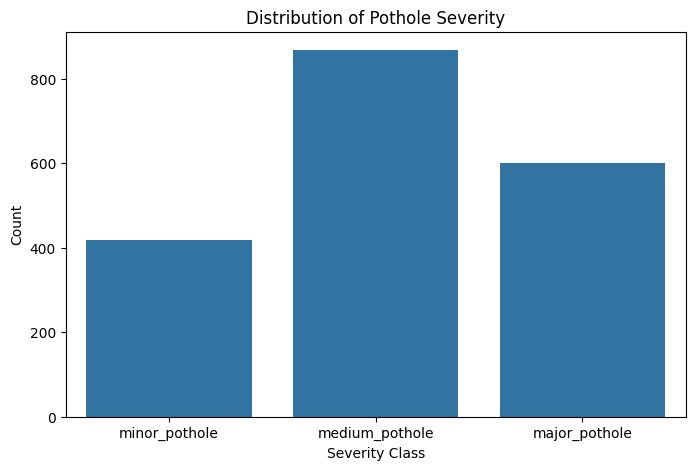

In [5]:

os.makedirs('../outputs/figures', exist_ok=True)

# 1. Severity Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', order=['minor_pothole', 'medium_pothole', 'major_pothole'])
plt.title('Distribution of Pothole Severity')
plt.xlabel('Severity Class')
plt.ylabel('Count')
plt.savefig('../outputs/figures/severity_distribution.png')
plt.show()


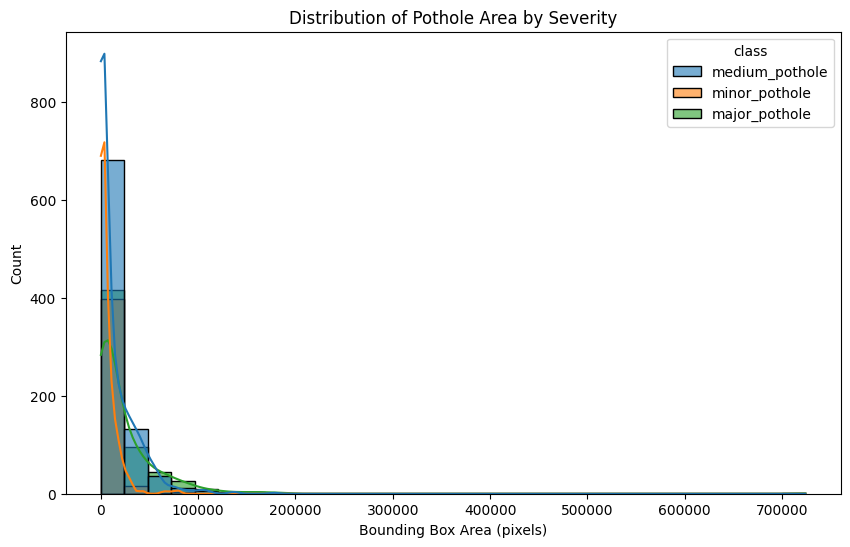

In [6]:

# 2. Numerical Distributions (Pothole Area)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='bbox_area', hue='class', kde=True, bins=30, alpha=0.6)
plt.title('Distribution of Pothole Area by Severity')
plt.xlabel('Bounding Box Area (pixels)')
plt.savefig('../outputs/figures/area_distribution.png')
plt.show()


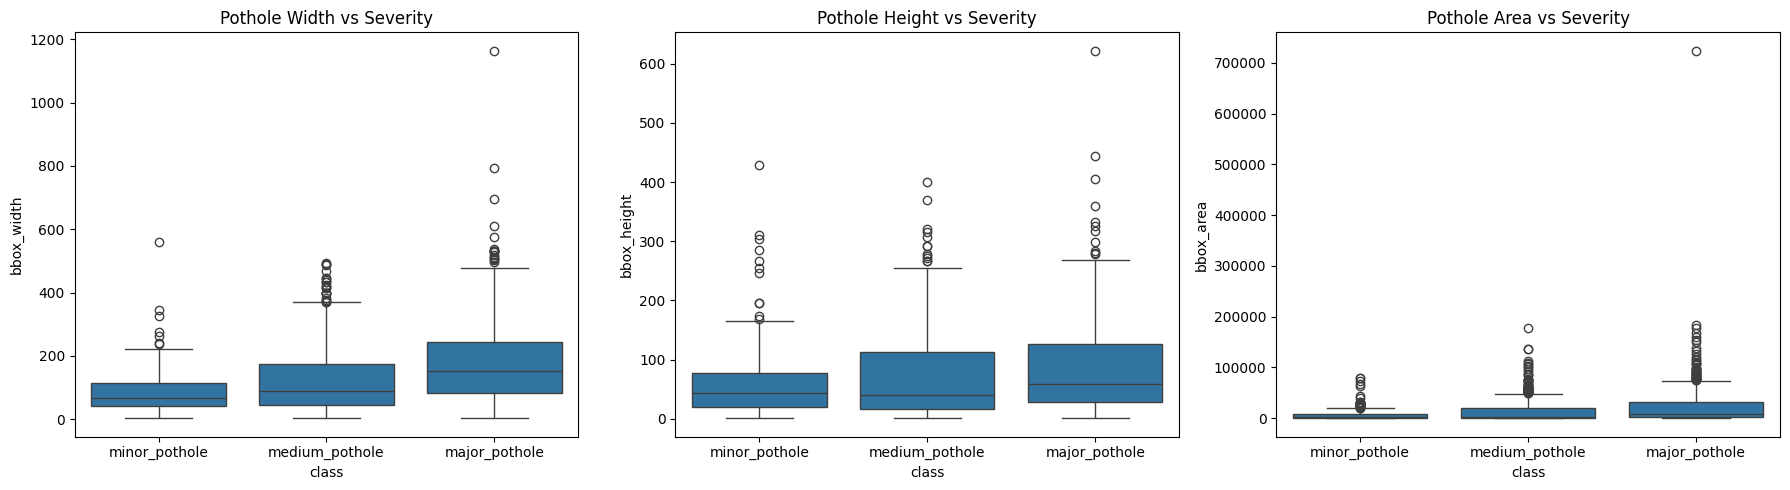

In [7]:

# 3. Boxplots comparing dimensions across severity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='class', y='bbox_width', ax=axes[0], order=['minor_pothole', 'medium_pothole', 'major_pothole'])
axes[0].set_title('Pothole Width vs Severity')

sns.boxplot(data=df, x='class', y='bbox_height', ax=axes[1], order=['minor_pothole', 'medium_pothole', 'major_pothole'])
axes[1].set_title('Pothole Height vs Severity')

sns.boxplot(data=df, x='class', y='bbox_area', ax=axes[2], order=['minor_pothole', 'medium_pothole', 'major_pothole'])
axes[2].set_title('Pothole Area vs Severity')

plt.tight_layout()
plt.savefig('../outputs/figures/dimension_boxplots.png')
plt.show()


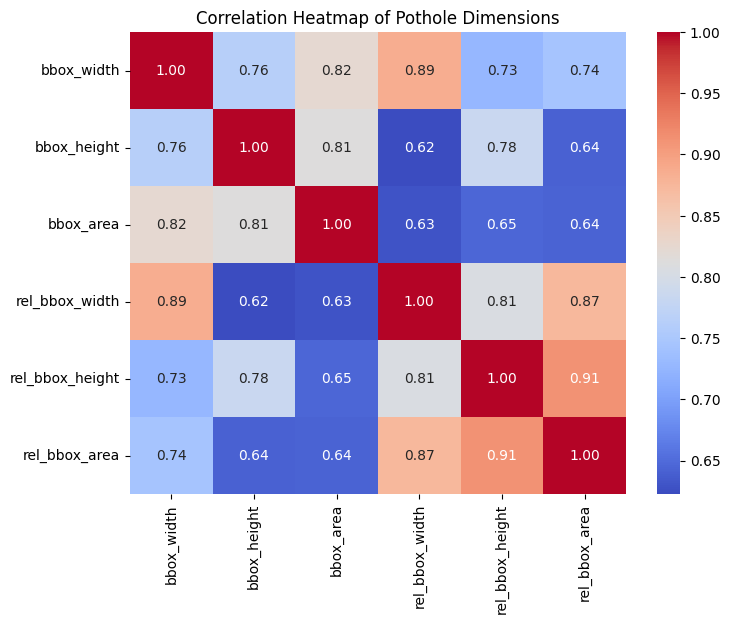

In [8]:

# 4. Correlation Heatmap for Numerical Variables
numerical_cols = ['bbox_width', 'bbox_height', 'bbox_area', 'rel_bbox_width', 'rel_bbox_height', 'rel_bbox_area']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Pothole Dimensions')
plt.savefig('../outputs/figures/correlation_heatmap.png')
plt.show()


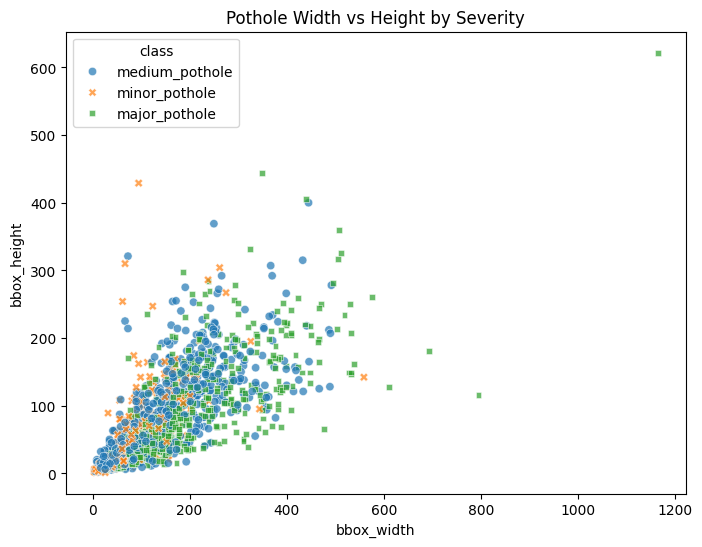

In [9]:

# 5. Scatterplot of Width vs Height colored by Severity
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bbox_width', y='bbox_height', hue='class', style='class', alpha=0.7)
plt.title('Pothole Width vs Height by Severity')
plt.savefig('../outputs/figures/width_vs_height_scatter.png')
plt.show()


## 5. Road Condition Analysis

The internship requires road deterioration analysis. However, as documented during data understanding, **the dataset does not contain specific road-condition fields, location data, traffic exposure, or maintenance cost history**. The dataset is strictly an image-based object detection dataset providing bounding box dimensions and severity classes for individual potholes. We explicitly document this limitation; no fake road-condition data will be fabricated.

In [10]:

# Generate EDA Report
report_content = """# EDA Report

## 1. Dataset Overview
- The dataset consists of XML annotations mapping to images.
- Extracted structured data has {rows} rows and {cols} columns.

## 2. Target Variable
- Target variable is `class`.
- Classes: {classes}
- There is a noticeable imbalance.

## 3. Missing Variables (Limitations)
- No road condition variables.
- No location/segment information.
- No traffic exposure or environmental variables.
- No maintenance cost fields.

## 4. Key Findings
- **Pothole Dimensions**: Major potholes generally exhibit larger bounding box areas, widths, and heights compared to minor and medium potholes.
- **Correlations**: Width, height, and area are strongly positively correlated, as expected.
- **Severity Patterns**: The physical size of the pothole in the image strongly relates to its annotated severity.

""".format(
    rows=df.shape[0],
    cols=df.shape[1],
    classes=", ".join(df['class'].unique())
)

with open('../reports/EDA_Report.md', 'w') as f:
    f.write(report_content)

print("EDA Report generated at reports/EDA_Report.md")


EDA Report generated at reports/EDA_Report.md
